In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# import the data
df = pd.read_csv("C:/Work/Projects/EV-Adoption-and-Range-Anxiety/01_Data/EV_adoption_and_Range_Anxiety_Dataset.csv")

In [3]:
# create a copy of the data
df_clean = df.copy()

In [4]:
# Display the first 5 rows of the dataframe
df_clean.head(5)

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
0,EV00001,56,Male,44906.0,Rural,18.1,1,Truck,1,0,Yes,4.0,Yes,Low,No
1,EV00002,36,Male,88754.0,Rural,5.0,1,SUV,2,3,Yes,1.0,Yes,Low,No
2,EV00003,42,Male,155958.0,Urban,32.2,2,Sedan,14,3,No,2.0,Yes,Medium,Yes
3,EV00004,31,Male,37059.0,Rural,89.9,1,Sedan,2,1,Yes,4.0,No,Low,No
4,EV00005,48,Female,48552.0,Rural,71.0,1,Sedan,2,0,Yes,3.0,Yes,Low,No


In [5]:
# Display the last 5 rows of the dataframe
df_clean.tail(5)

,Buyer_ID,Age,Gender,Annual_Income_USD,City_Type,Daily_Commute_km,Number_of_Cars_Owned,Current_Car_Type,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Home_Charging_Possible,Environmental_Concern_Level,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV
9995,EV09996,50,Male,61279.0,Urban,71.4,1,Sedan,8,3,No,3.0,Yes,Medium,No
9996,EV09997,34,Male,108208.0,Urban,48.0,2,Hatchback,9,7,No,5.0,No,Low,No
9997,EV09998,60,Female,97743.0,Urban,9.0,2,Sedan,10,3,No,5.0,Yes,Low,No
9998,EV09999,31,Female,103628.0,Urban,81.8,2,SUV,10,10,Yes,1.0,Yes,Low,No
9999,EV10000,64,Other,59052.0,Suburban,24.0,2,Hatchback,1,9,Yes,5.0,Yes,Low,No


In [6]:
# shape of the data
df_clean.shape

(10000, 15)

In [7]:
# Display the column names
df_clean.columns

Index(['Buyer_ID', 'Age', 'Gender', 'Annual_Income_USD', 'City_Type',
       'Daily_Commute_km', 'Number_of_Cars_Owned', 'Current_Car_Type',
       'Charging_Stations_Near_Home', 'Charging_Stations_Near_Work',
       'Home_Charging_Possible', 'Environmental_Concern_Level',
       'Subsidy_Available', 'Range_Anxiety_Level', 'Will_Buy_EV'],
      dtype='str')

In [8]:
# convert column name into lower case letters
df_clean.columns = df_clean.columns.str.lower()

In [9]:
# Display the basic information
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   buyer_id                     10000 non-null  str    
 1   age                          10000 non-null  int64  
 2   gender                       10000 non-null  str    
 3   annual_income_usd            9822 non-null   float64
 4   city_type                    10000 non-null  str    
 5   daily_commute_km             9819 non-null   float64
 6   number_of_cars_owned         10000 non-null  int64  
 7   current_car_type             10000 non-null  str    
 8   charging_stations_near_home  10000 non-null  int64  
 9   charging_stations_near_work  10000 non-null  int64  
 10  home_charging_possible       10000 non-null  str    
 11  environmental_concern_level  9816 non-null   float64
 12  subsidy_available            10000 non-null  str    
 13  range_anxiety_level         

# Data Cleaning

In [10]:
# check the missing values
df_clean.isnull().sum()

buyer_id                         0
age                              0
gender                           0
annual_income_usd              178
city_type                        0
daily_commute_km               181
number_of_cars_owned             0
current_car_type                 0
charging_stations_near_home      0
charging_stations_near_work      0
home_charging_possible           0
environmental_concern_level    184
subsidy_available                0
range_anxiety_level              0
will_buy_ev                      0
dtype: int64

In [11]:
# Return rows that contain missing values in  annual_income column
df_clean[df_clean["annual_income_usd"].isnull()]

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev
35,EV00036,60,Male,NaN,Urban,33.1,4,SUV,6,12,No,4.0,No,Medium,No
58,EV00059,60,Male,NaN,Rural,32.9,2,Hatchback,0,0,Yes,5.0,Yes,Low,Yes
70,EV00071,34,Female,NaN,Suburban,69.6,2,SUV,4,2,Yes,3.0,Yes,Low,Yes
128,EV00129,36,Female,NaN,Suburban,55.1,2,Sedan,1,9,Yes,2.0,No,Low,No
142,EV00143,61,Male,NaN,Suburban,35.2,2,Sedan,7,5,Yes,1.0,No,Low,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9672,EV09673,50,Female,NaN,Suburban,76.8,2,Sedan,6,5,Yes,1.0,Yes,Low,No
9765,EV09766,38,Female,NaN,Urban,45.1,1,SUV,8,6,No,3.0,No,Medium,No
9845,EV09846,39,Female,NaN,Urban,44.1,1,SUV,10,3,Yes,2.0,No,Low,No
9951,EV09952,50,Male,NaN,Urban,62.3,1,Hatchback,12,12,No,1.0,Yes,Low,No


In [12]:
# Check the percentage of missing values in annual_income column
(df_clean["annual_income_usd"].isna().sum()/len(df_clean)) * 100

np.float64(1.78)

In [13]:
# Investigate missing values in annual income column to see if they follow a pattern
# Missing values by Age Group
df_clean[df_clean["annual_income_usd"].isna()]["age"].value_counts()

age
49    10
50     9
65     8
40     7
31     7
28     6
27     6
54     6
32     6
35     6
34     5
37     5
59     5
38     5
60     4
36     4
61     4
52     4
43     4
26     4
62     4
25     4
55     4
58     4
33     3
63     3
48     3
45     3
44     3
56     3
29     3
66     3
39     3
41     2
68     2
47     2
46     2
67     2
51     2
64     2
57     2
42     2
53     1
30     1
Name: count, dtype: int64

In [14]:
# Missing Annual_Income_USD by gender
df_clean[df_clean["annual_income_usd"].isnull()]["gender"].value_counts()


gender
Female    87
Male      86
Other      5
Name: count, dtype: int64

In [15]:
# Check missing values in Percentage

In [16]:
# missing values by percentage in Gender column
(
    df_clean.groupby("gender")["annual_income_usd"]
    .apply(lambda x: x.isnull().mean() * 100)
)

gender
Female    1.934193
Male      1.653528
Other     1.661130
Name: annual_income_usd, dtype: float64

In [17]:
# Missing Values by City Type
(
    df_clean.groupby("city_type")["annual_income_usd"]
    .apply(lambda x: x.isnull().mean()* 100)
)    

city_type
Rural       1.537433
Suburban    1.852372
Urban       1.801255
Name: annual_income_usd, dtype: float64

In [18]:
# Missing values by Current Car Types
(
    df_clean.groupby("current_car_type")["annual_income_usd"]
    .apply(lambda x: x.isna().mean() * 100)
)

current_car_type
Hatchback    1.444517
SUV          1.921974
Sedan        1.850000
Truck        1.513623
Name: annual_income_usd, dtype: float64

In [19]:
# missing values by Charging station near home
(
    df_clean.groupby("charging_stations_near_home")["annual_income_usd"]
    .apply(lambda x: x.isnull().mean() * 100)
)

charging_stations_near_home
0     1.609442
1     1.449275
2     1.536098
3     1.607348
4     2.017654
5     1.701094
6     2.430134
7     1.796407
8     1.608579
9     2.349869
10    1.923077
11    2.244389
12    1.837270
13    1.315789
14    1.876676
Name: annual_income_usd, dtype: float64

In [20]:
# Missing values by Charging station near Work
(
    df_clean.groupby("charging_stations_near_work")["annual_income_usd"]
    .apply(lambda x: x.isnull().mean() * 100)
)

charging_stations_near_work
0     1.583113
1     1.307190
2     1.994302
3     1.419111
4     1.769912
5     1.977401
6     2.231520
7     1.920236
8     1.390821
9     1.699717
10    3.092784
11    1.063830
12    1.655629
13    1.351351
14    2.380952
15    1.811594
16    1.655629
17    2.456140
18    1.724138
19    2.189781
Name: annual_income_usd, dtype: float64

In [21]:
# Missing values by Homecharging possible
(
    df_clean.groupby("home_charging_possible")["annual_income_usd"]
    .apply(lambda x: x.isnull().mean() * 100)
)

home_charging_possible
No     1.876466
Yes    1.719942
Name: annual_income_usd, dtype: float64

In [22]:
# Missing values by Range Anxiety
(
    df_clean.groupby("range_anxiety_level")["annual_income_usd"]
    .apply(lambda x: x.isnull().mean() * 100)
)

range_anxiety_level
High      0.598802
Low       1.817088
Medium    1.707157
Name: annual_income_usd, dtype: float64

In [23]:
# Missing Values by Subsidy available
(
    df_clean.groupby("subsidy_available")["annual_income_usd"]
    .apply(lambda x: x.isnull().mean() * 100)
)    

subsidy_available
No     1.653307
Yes    1.864181
Name: annual_income_usd, dtype: float64

In [24]:
# Missing values by will buy
(
    df_clean.groupby("will_buy_ev")["annual_income_usd"]
    .apply(lambda x: x.isnull().mean() * 100)
)

will_buy_ev
No     1.612121
Yes    2.571429
Name: annual_income_usd, dtype: float64

In [25]:
# mssing values by age group
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins=[18, 30, 40, 50, 60, 70],
    labels=["18-30", "31-40", "41-50", "51-60", "61-70"]
)

(
    df_clean.groupby("age_group")["annual_income_usd"]
    .apply(lambda x: x.isnull().mean() * 100)
)

age_group
18-30    1.793722
31-40    2.305606
41-50    1.735358
51-60    1.612903
61-70    1.417722
Name: annual_income_usd, dtype: float64

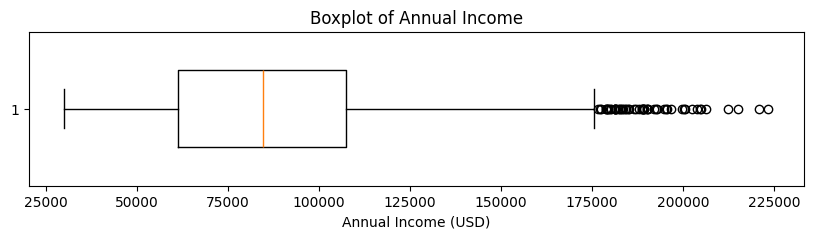

In [26]:
# Boxplot of annual income column 
plt.figure(figsize=(10, 2))

plt.boxplot(
    df_clean["annual_income_usd"].dropna(),
    vert=False,
    widths=0.5
)

plt.title("Boxplot of Annual Income")
plt.xlabel("Annual Income (USD)")
plt.show()

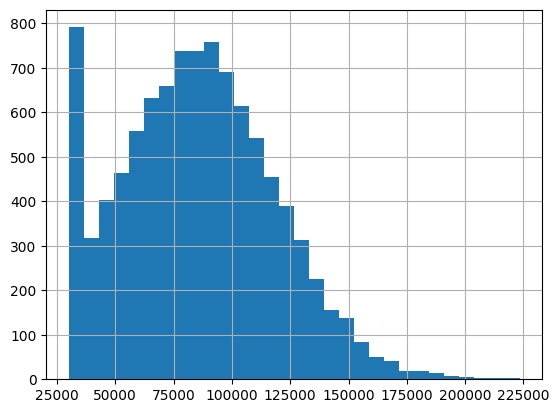

In [27]:
# Histogram
df_clean["annual_income_usd"].describe()

df_clean["annual_income_usd"].hist(bins=30)
plt.show()

In [28]:
# check if data is skewed
df_clean["annual_income_usd"].skew()

np.float64(0.305157007195843)

In [29]:
# check the summary statistics of annual income column
df_clean["annual_income_usd"].describe()

count      9822.000000
mean      85378.485848
std       32838.684167
min       30000.000000
25%       61369.500000
50%       84708.000000
75%      107383.250000
max      223345.000000
Name: annual_income_usd, dtype: float64

In [30]:
# Missing Value Treatment: The annual_income_usd column contained 178 missing values (1.78% of the dataset). Missingness was analyzed across demographic and behavioral variables, including gender, age group, city type, car type, charging availability, subsidy availability, range anxiety, and EV purchase intention. Since missing percentages were similar across most groups, no strong systematic pattern was identified. Therefore, the missing values were imputed using the median annual income to preserve the dataset while minimizing the influence of outliers.

In [31]:
# Fill missing values in Annual Income columns using median
df_clean["annual_income_usd"] = df_clean["annual_income_usd"].fillna(
    df_clean["annual_income_usd"].median()
)

In [32]:
# We had  fill missing values in annual income column by using median instead of mean so the value will not affected by outliers. 

In [33]:
# Check the number of missing values in Daily_Commute_km
df_clean["daily_commute_km"].isnull().sum()

np.int64(181)

In [34]:
# check the percentage of missing values in daily_commute_km column
(df_clean["daily_commute_km"].isnull().sum() / len(df_clean)) * 100

np.float64(1.81)

In [35]:
# Check whether the missing values follow a pattern
# missing values by Gender in percentage
(
    df_clean.groupby("gender")["daily_commute_km"]
    .apply(lambda x: x.isna().mean() * 100)
)    

gender
Female    1.556247
Male      2.057297
Other     1.328904
Name: daily_commute_km, dtype: float64

In [36]:
# missing values by Age Group
df_clean["age_group"] = pd.cut(
    df_clean["age"],
    bins= [18, 30, 40, 50, 60, 70],
    labels= ["18-30", "31-40", "41-50", "51-60", "61-70"]
)

(
    df_clean.groupby("age_group")["daily_commute_km"]
    .apply(lambda x: x.isna().mean()*100)
)

age_group
18-30    1.793722
31-40    1.356239
41-50    1.908894
51-60    1.797235
61-70    2.227848
Name: daily_commute_km, dtype: float64

In [37]:
# missing values by city type
(
    df_clean.groupby("city_type")["daily_commute_km"]
    .apply(lambda x: x.isnull().mean()*100)
)

city_type
Rural       1.604278
Suburban    1.964637
Urban       1.760777
Name: daily_commute_km, dtype: float64

In [38]:
# missing value by current car type
(
    df_clean.groupby("current_car_type")["daily_commute_km"]
    .apply(lambda x: x.isna().mean() * 100)
)

current_car_type
Hatchback    1.116218
SUV          1.950660
Sedan        1.800000
Truck        2.421796
Name: daily_commute_km, dtype: float64

In [39]:
# missing values by Home Charging Possible
(
    df_clean.groupby("home_charging_possible")["daily_commute_km"]
    .apply(lambda x: x.isna().mean()* 100)
)    

home_charging_possible
No     1.798280
Yes    1.817297
Name: daily_commute_km, dtype: float64

In [40]:
# Missig values by Subsidy Available
(
    df_clean.groupby("subsidy_available")["daily_commute_km"]
    .apply(lambda x: x.isna().mean()*100)
)

subsidy_available
No     1.903808
Yes    1.747670
Name: daily_commute_km, dtype: float64

In [41]:
# Missing values by Will buy EV
(
    df_clean.groupby("will_buy_ev")["daily_commute_km"]
    .apply(lambda x: x.isna().mean()*100)
)

will_buy_ev
No     1.781818
Yes    1.942857
Name: daily_commute_km, dtype: float64

In [42]:
# missing values by Range Anxiety Level
(
    df_clean.groupby("range_anxiety_level")["daily_commute_km"]
    .apply(lambda x: x.isna().mean()*100)
)

range_anxiety_level
High      1.796407
Low       1.889290
Medium    1.378858
Name: daily_commute_km, dtype: float64

In [43]:
# Check the distribution in daily commute column
df_clean["daily_commute_km"].describe()

count    9819.000000
mean       41.105418
std        23.351276
min         5.000000
25%        23.250000
50%        40.200000
75%        57.000000
max       135.500000
Name: daily_commute_km, dtype: float64

In [44]:
# check if the data is skewed
df_clean["daily_commute_km"].skew()

np.float64(0.33613687113985224)

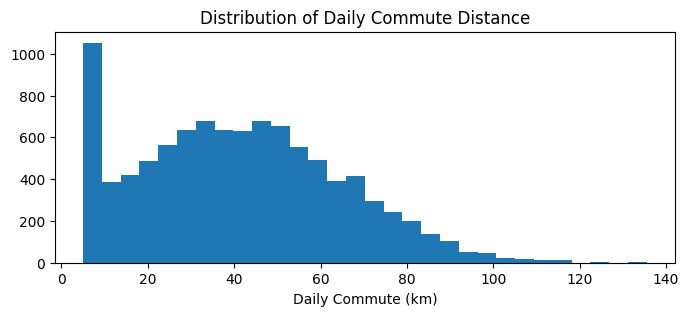

In [45]:
# Create the histgram
plt.figure(figsize=(8, 3))
plt.hist(df_clean["daily_commute_km"].dropna(), bins= 30)
plt.title("Distribution of Daily Commute Distance")
plt.xlabel("Daily Commute (km)")
plt.show()

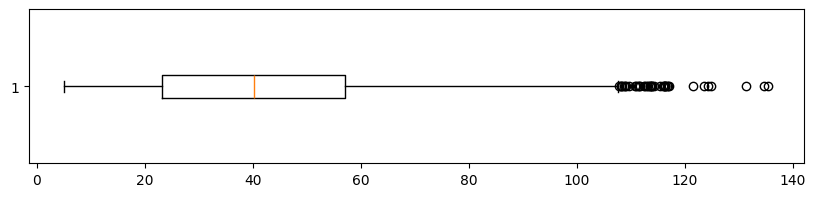

In [46]:
# Boxplot
plt.figure(figsize=(10,2))
plt.boxplot(df_clean["daily_commute_km"].dropna(), vert=False)
plt.show()

In [47]:
# The daily_commute_km column contained 181 missing values (1.81%). Missingness was examined across demographic and behavioral variables and showed no meaningful differences between groups, suggesting the values were approximately missing at random. The distribution was approximately symmetric (skewness = 0.336), so the missing values were imputed using the median to provide a robust and consistent treatment.

In [48]:
# Median of daily commute km column
df_clean["daily_commute_km"].median()

np.float64(40.2)

In [49]:
# Fill missing values in Daily Commute Km using median
df_clean["daily_commute_km"] = df_clean["daily_commute_km"].fillna(
    df_clean["daily_commute_km"].median()
)

In [50]:
# Missing values in Environmental Concern Level Column

In [51]:
df_clean["environmental_concern_level"].value_counts()

environmental_concern_level
1.0    2013
4.0    1989
3.0    1958
2.0    1948
5.0    1908
Name: count, dtype: int64

In [52]:
# Calculate the missing value percentages in Environmetal_Concern_Level Column
(df_clean["environmental_concern_level"].isna().sum() / len(df_clean)) * 100

np.float64(1.8399999999999999)

In [53]:
# Check the Distribution 
df_clean["environmental_concern_level"].value_counts(dropna=False)

environmental_concern_level
1.0    2013
4.0    1989
3.0    1958
2.0    1948
5.0    1908
NaN     184
Name: count, dtype: int64

In [54]:
# Check the median
df_clean["environmental_concern_level"].median()

np.float64(3.0)

In [55]:
# Fill the missing values in environmental concern level column with median
df_clean["environmental_concern_level"] = df_clean["environmental_concern_level"].fillna(df_clean["environmental_concern_level"].median())

In [56]:
# Verify that there is missing values in the data after filling missing values
df_clean.isna().sum()

buyer_id                       0
age                            0
gender                         0
annual_income_usd              0
city_type                      0
daily_commute_km               0
number_of_cars_owned           0
current_car_type               0
charging_stations_near_home    0
charging_stations_near_work    0
home_charging_possible         0
environmental_concern_level    0
subsidy_available              0
range_anxiety_level            0
will_buy_ev                    0
age_group                      0
dtype: int64

In [57]:
# Check the duplicatevalue in the data
df_clean.duplicated().sum()

np.int64(0)

In [58]:
# There is no duplicate value in the data

In [59]:
# Check the datatypes in each columns 
df_clean.dtypes

buyer_id                            str
age                               int64
gender                              str
annual_income_usd               float64
city_type                           str
daily_commute_km                float64
number_of_cars_owned              int64
current_car_type                    str
charging_stations_near_home       int64
charging_stations_near_work       int64
home_charging_possible              str
environmental_concern_level     float64
subsidy_available                   str
range_anxiety_level                 str
will_buy_ev                         str
age_group                      category
dtype: object

In [60]:
# Convert Environmetal concern level column into integar data types
df_clean["environmental_concern_level"] = (
    df_clean["environmental_concern_level"].astype("int64")
)

In [61]:
# check if environmental_concern_level column is converted into int
df_clean["environmental_concern_level"].dtypes

dtype('int64')

In [62]:
# Check if there is an outlier using iqr method
numerical_cols = df_clean.select_dtypes(include= np.number).columns
for col in numerical_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

age: 0 outliers
annual_income_usd: 58 outliers
daily_commute_km: 44 outliers
number_of_cars_owned: 511 outliers
charging_stations_near_home: 0 outliers
charging_stations_near_work: 0 outliers
environmental_concern_level: 0 outliers


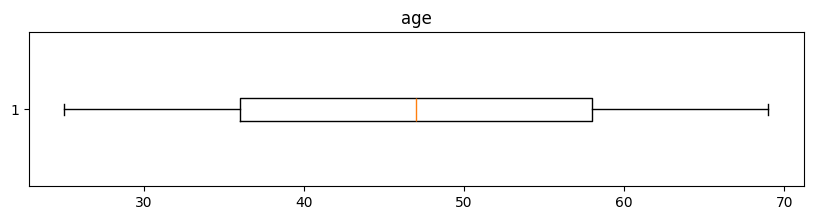

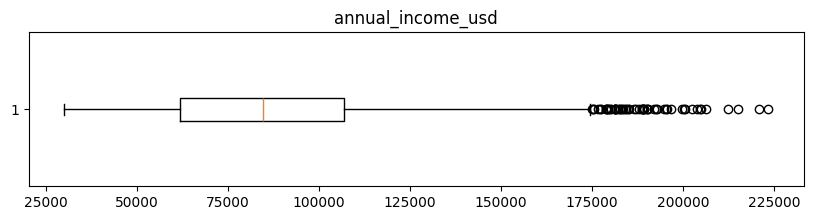

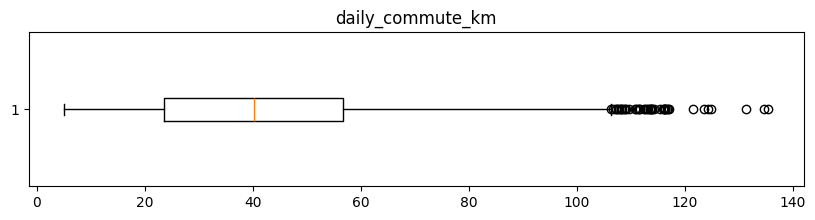

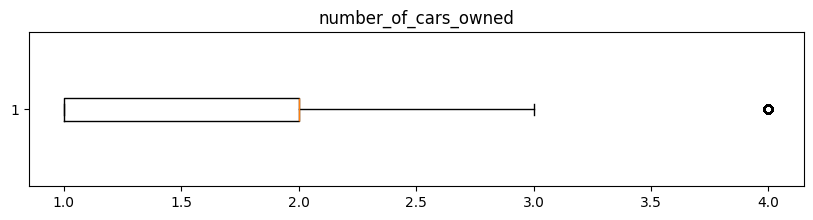

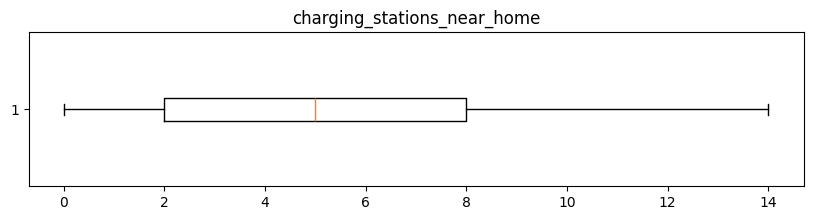

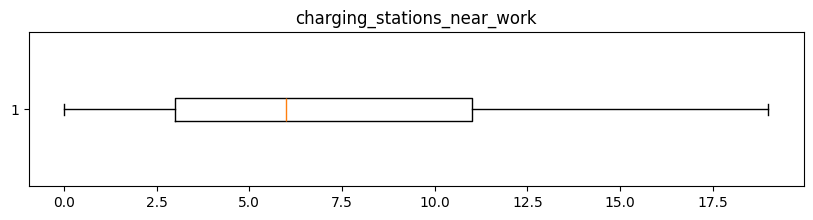

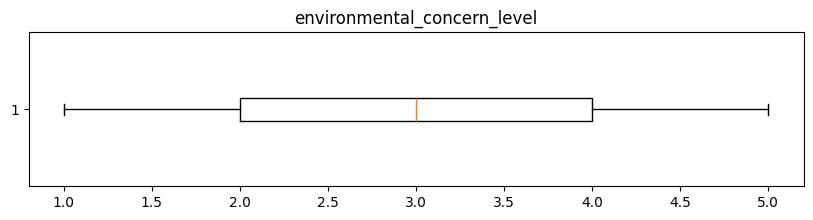

In [63]:
# using boxplot
for col in numerical_cols:
    plt.figure(figsize=(10, 2))
    plt.boxplot(df_clean[col], vert = False)
    plt.title(col)
    plt.show()

In [64]:
# outliers in annual_income 
df_clean["annual_income_usd"].describe()


count     10000.000000
mean      85366.551200
std       32545.198864
min       30000.000000
25%       61883.500000
50%       84708.000000
75%      106938.500000
max      223345.000000
Name: annual_income_usd, dtype: float64

In [65]:
# In annual income column there can be some customers who earn high income so we shold keep them 

In [66]:
# in daily_distance_km column
df_clean["daily_commute_km"].describe()

count    10000.000000
mean        41.089030
std         23.139275
min          5.000000
25%         23.600000
50%         40.200000
75%         56.700000
max        135.500000
Name: daily_commute_km, dtype: float64

In [67]:
# in this there can be some buyers whose daily commute is high but it can possible that their daily commute is long.  

In [68]:
df_clean["number_of_cars_owned"].value_counts().sort_index()

number_of_cars_owned
1    3946
2    4020
3    1523
4     511
Name: count, dtype: int64

In [69]:
# Outlier Analysis: IQR analysis identified 511 observations in number_of_cars_owned as statistical outliers. However, further investigation showed that these observations correspond to customers owning 4 cars. Since owning 4 cars is a valid and plausible value, these observations were retained rather than removed.

In [70]:
# Display basic info. of categorical columns
df_clean.describe(include="str")

,buyer_id,gender,city_type,current_car_type,home_charging_possible,subsidy_available,range_anxiety_level,will_buy_ev
count,10000,10000,10000,10000,10000,10000,10000,10000
unique,10000,3,3,4,2,2,3,2
top,EV00001,Male,Urban,Sedan,Yes,Yes,Low,No
freq,1,5201,4941,4000,6163,6008,8310,8250


In [71]:
# Display the unique values in str columns
categorical_cols = df_clean.select_dtypes(include="str").columns
for col in categorical_cols:
    print(f"{df_clean[col].value_counts()}")

buyer_id
EV00001    1
EV00002    1
EV00003    1
EV00004    1
EV00005    1
          ..
EV09996    1
EV09997    1
EV09998    1
EV09999    1
EV10000    1
Name: count, Length: 10000, dtype: int64
gender
Male      5201
Female    4498
Other      301
Name: count, dtype: int64
city_type
Urban       4941
Suburban    3563
Rural       1496
Name: count, dtype: int64
current_car_type
Sedan        4000
SUV          3486
Hatchback    1523
Truck         991
Name: count, dtype: int64
home_charging_possible
Yes    6163
No     3837
Name: count, dtype: int64
subsidy_available
Yes    6008
No     3992
Name: count, dtype: int64
range_anxiety_level
Low       8310
Medium    1523
High       167
Name: count, dtype: int64
will_buy_ev
No     8250
Yes    1750
Name: count, dtype: int64


# Data Validation

In [72]:
# Data validation
# Annual Income Valiations
# Check if annual_income is 0 or is -ve
df_clean[df_clean["annual_income_usd"] <= 0]

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev,age_group


In [73]:
# Display basic statistics of column 
df_clean["annual_income_usd"].describe()

count     10000.000000
mean      85366.551200
std       32545.198864
min       30000.000000
25%       61883.500000
50%       84708.000000
75%      106938.500000
max      223345.000000
Name: annual_income_usd, dtype: float64

In [74]:
# check missing values
df_clean["annual_income_usd"].isna().sum()

np.int64(0)

In [75]:
# check datatypes
df_clean["annual_income_usd"].dtype

dtype('float64')

In [76]:
# Age Validation
# Check the age column
df_clean["age"].describe()

count    10000.000000
mean        46.936200
std         12.945968
min         25.000000
25%         36.000000
50%         47.000000
75%         58.000000
max         69.000000
Name: age, dtype: float64

In [77]:
# check if age is greater than 18 and less than 100 
df_clean[(df_clean["age"] < 18) | (df_clean["age"] > 100)]

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev,age_group


In [78]:
# check missing values
df_clean["age"].isnull().sum()

np.int64(0)

In [79]:
# data types of age column
df_clean["age"].dtype


dtype('int64')

In [80]:
# Daily commute validation
df_clean["daily_commute_km"].describe()

count    10000.000000
mean        41.089030
std         23.139275
min          5.000000
25%         23.600000
50%         40.200000
75%         56.700000
max        135.500000
Name: daily_commute_km, dtype: float64

In [81]:
# check -ve or zero values
df_clean[df_clean["daily_commute_km"] <= 0]

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev,age_group


In [82]:
# Number of cars owned Validation
# Basic statistics
df_clean["number_of_cars_owned"].describe()

count    10000.000000
mean         1.859900
std          0.855421
min          1.000000
25%          1.000000
50%          2.000000
75%          2.000000
max          4.000000
Name: number_of_cars_owned, dtype: float64

In [83]:
# check invalid values
df_clean[df_clean["number_of_cars_owned"] <= 0]

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev,age_group


In [84]:
# check unique values
df_clean["number_of_cars_owned"].unique()

array([1, 2, 3, 4])

In [85]:
# Charging stations near home Validation
df_clean["charging_stations_near_home"].describe()

count    10000.000000
mean         5.346900
std          4.049074
min          0.000000
25%          2.000000
50%          5.000000
75%          8.000000
max         14.000000
Name: charging_stations_near_home, dtype: float64

In [86]:
# check -ve values
df_clean[df_clean["charging_stations_near_home"] < 0]

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev,age_group


In [87]:
# unique values
df_clean["charging_stations_near_home"].unique()

array([ 1,  2, 14,  6, 13,  5,  8, 12,  7,  0,  9,  4, 10, 11,  3])

In [88]:
# Charging stations near work
df_clean["charging_stations_near_work"].describe()

count    10000.000000
mean         7.458200
std          5.259374
min          0.000000
25%          3.000000
50%          6.000000
75%         11.000000
max         19.000000
Name: charging_stations_near_work, dtype: float64

In [89]:
# check -ve values
df_clean[df_clean["charging_stations_near_work"] < 0]

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev,age_group


In [90]:
# unique values
df_clean["charging_stations_near_work"].unique()

array([ 0,  3,  1,  8,  2, 10,  6,  9,  4, 19, 16,  5, 12, 18, 14, 11,  7,
       13, 15, 17])

In [91]:
# Environmental concern level
df_clean["environmental_concern_level"].describe()

count    10000.000000
mean         2.983100
std          1.400718
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: environmental_concern_level, dtype: float64

In [92]:
# check if comtains values less than 1 and more than 5 it should contain 1-5
df_clean[
    (df_clean["environmental_concern_level"] <1) |
    (df_clean["environmental_concern_level"] > 5)
]

,buyer_id,age,gender,annual_income_usd,city_type,daily_commute_km,number_of_cars_owned,current_car_type,charging_stations_near_home,charging_stations_near_work,home_charging_possible,environmental_concern_level,subsidy_available,range_anxiety_level,will_buy_ev,age_group


In [93]:
# unique values
df_clean["environmental_concern_level"].unique()

array([4, 1, 2, 3, 5])

In [94]:
# Gender
df_clean["gender"].value_counts(dropna=False)

gender
Male      5201
Female    4498
Other      301
Name: count, dtype: int64

In [95]:
# City Type
df_clean["city_type"].value_counts(dropna=False)

city_type
Urban       4941
Suburban    3563
Rural       1496
Name: count, dtype: int64

In [96]:
# Current car type
df_clean["current_car_type"].value_counts(dropna=False)

current_car_type
Sedan        4000
SUV          3486
Hatchback    1523
Truck         991
Name: count, dtype: int64

In [97]:
# home_charging_possible
df_clean["home_charging_possible"].value_counts(dropna=False)

home_charging_possible
Yes    6163
No     3837
Name: count, dtype: int64

In [98]:
df_clean["subsidy_available"].value_counts(dropna=False)

subsidy_available
Yes    6008
No     3992
Name: count, dtype: int64

In [99]:
df_clean["will_buy_ev"].value_counts(dropna=False)

will_buy_ev
No     8250
Yes    1750
Name: count, dtype: int64

In [100]:
# Range anxiety
df_clean["range_anxiety_level"].value_counts(dropna=False)

range_anxiety_level
Low       8310
Medium    1523
High       167
Name: count, dtype: int64

In [101]:
# Buyer ID validation
df_clean["buyer_id"].duplicated().sum()

np.int64(0)

# EDA

In [102]:
# Overview of the data
df_clean.shape

(10000, 16)

In [103]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   buyer_id                     10000 non-null  str     
 1   age                          10000 non-null  int64   
 2   gender                       10000 non-null  str     
 3   annual_income_usd            10000 non-null  float64 
 4   city_type                    10000 non-null  str     
 5   daily_commute_km             10000 non-null  float64 
 6   number_of_cars_owned         10000 non-null  int64   
 7   current_car_type             10000 non-null  str     
 8   charging_stations_near_home  10000 non-null  int64   
 9   charging_stations_near_work  10000 non-null  int64   
 10  home_charging_possible       10000 non-null  str     
 11  environmental_concern_level  10000 non-null  int64   
 12  subsidy_available            10000 non-null  str     
 13  range_anxiety

In [104]:
df_clean.describe()

,age,annual_income_usd,daily_commute_km,number_of_cars_owned,charging_stations_near_home,charging_stations_near_work,environmental_concern_level
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,46.936200,85366.551200,41.089030,1.859900,5.346900,7.458200,2.983100
std,12.945968,32545.198864,23.139275,0.855421,4.049074,5.259374,1.400718
min,25.000000,30000.000000,5.000000,1.000000,0.000000,0.000000,1.000000
25%,36.000000,61883.500000,23.600000,1.000000,2.000000,3.000000,2.000000
50%,47.000000,84708.000000,40.200000,2.000000,5.000000,6.000000,3.000000
75%,58.000000,106938.500000,56.700000,2.000000,8.000000,11.000000,4.000000
max,69.000000,223345.000000,135.500000,4.000000,14.000000,19.000000,5.000000


In [105]:
# For categorical columns
categorical_cols = df_clean.select_dtypes(
    include=["object", "string", "category"]
).columns

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts())


--- buyer_id ---
buyer_id
EV00001    1
EV00002    1
EV00003    1
EV00004    1
EV00005    1
          ..
EV09996    1
EV09997    1
EV09998    1
EV09999    1
EV10000    1
Name: count, Length: 10000, dtype: int64

--- gender ---
gender
Male      5201
Female    4498
Other      301
Name: count, dtype: int64

--- city_type ---
city_type
Urban       4941
Suburban    3563
Rural       1496
Name: count, dtype: int64

--- current_car_type ---
current_car_type
Sedan        4000
SUV          3486
Hatchback    1523
Truck         991
Name: count, dtype: int64

--- home_charging_possible ---
home_charging_possible
Yes    6163
No     3837
Name: count, dtype: int64

--- subsidy_available ---
subsidy_available
Yes    6008
No     3992
Name: count, dtype: int64

--- range_anxiety_level ---
range_anxiety_level
Low       8310
Medium    1523
High       167
Name: count, dtype: int64

--- will_buy_ev ---
will_buy_ev
No     8250
Yes    1750
Name: count, dtype: int64

--- age_group ---
age_group
41-50    2305
31

In [106]:
# check the target
df_clean["will_buy_ev"].value_counts()

will_buy_ev
No     8250
Yes    1750
Name: count, dtype: int64

In [107]:
# percentage of will buy ev 
df_clean["will_buy_ev"].value_counts(normalize= True) * 100

will_buy_ev
No     82.5
Yes    17.5
Name: proportion, dtype: float64

In [108]:
# Univariate Analysis
# What does each individual variable look like?

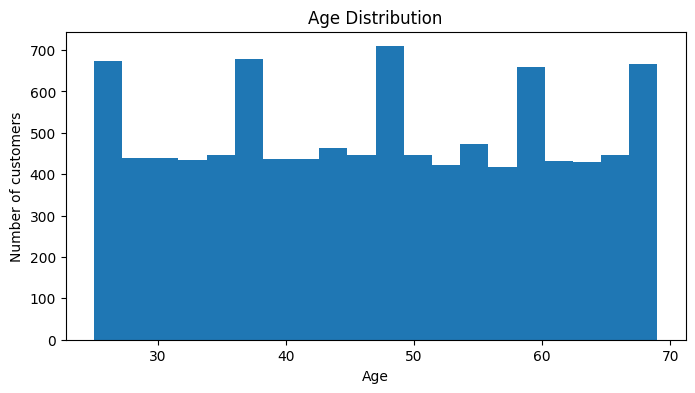

In [109]:
# Age
plt.figure(figsize=(8, 4))
plt.hist(df_clean["age"], bins = 20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of customers")
plt.show()

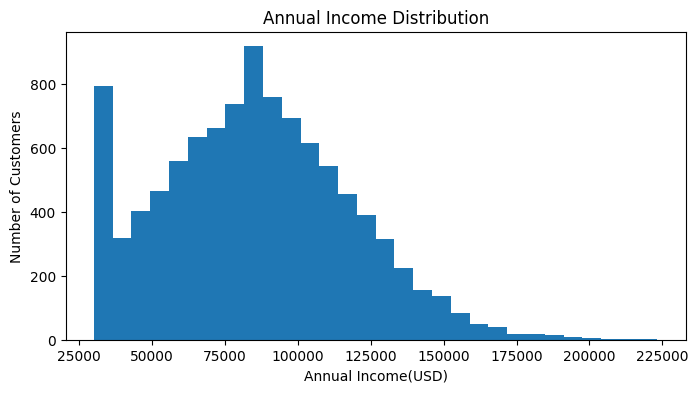

In [110]:
# Income
plt.figure(figsize=(8, 4))
plt.hist(df_clean["annual_income_usd"], bins= 30)
plt.title("Annual Income Distribution")
plt.xlabel("Annual Income(USD)")
plt.ylabel("Number of Customers")
plt.show()

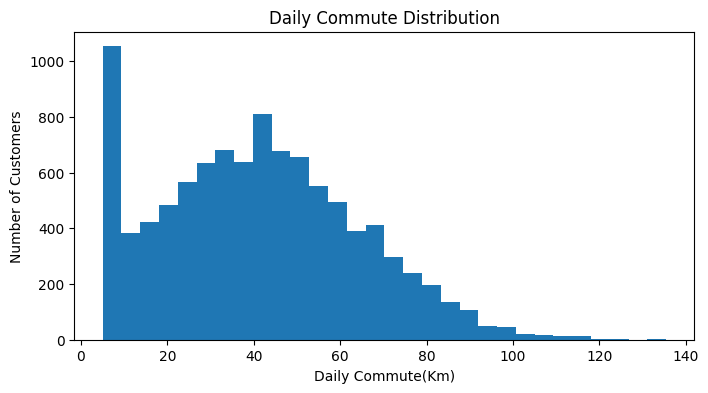

In [111]:
# Daily Commute Km
plt.figure(figsize=(8, 4))
plt.hist(df_clean["daily_commute_km"], bins= 30)
plt.title("Daily Commute Distribution")
plt.xlabel("Daily Commute(Km)")
plt.ylabel("Number of Customers")
plt.show()

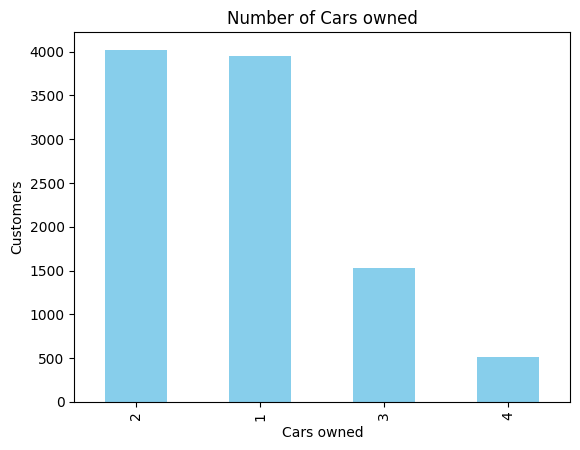

In [112]:
# Number of Cars owned - since this is a discrete columnns
df_clean["number_of_cars_owned"].value_counts().plot(kind = "bar", color = "skyblue")
plt.title("Number of Cars owned")
plt.xlabel("Cars owned")
plt.ylabel("Customers")
plt.show()

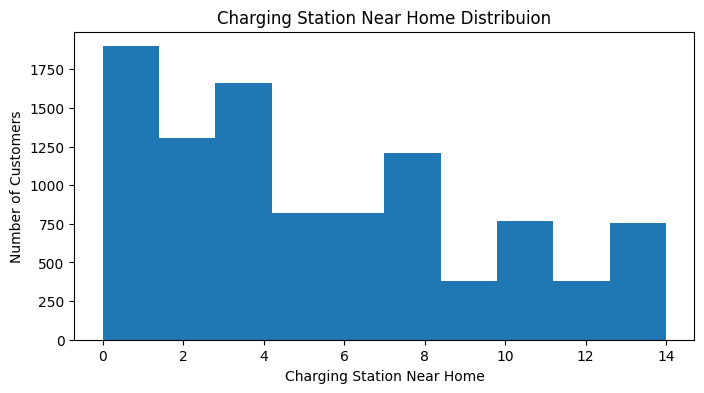

In [113]:
# Charging stations near home
plt.figure(figsize=(8, 4))
plt.hist(df_clean["charging_stations_near_home"], bins= 10)
plt.title("Charging Station Near Home Distribuion")
plt.xlabel("Charging Station Near Home")
plt.ylabel("Number of Customers")
plt.show()

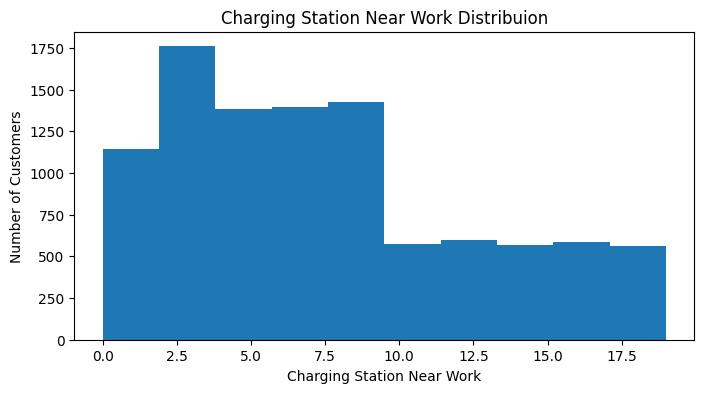

In [114]:
# Charging stations near work
plt.figure(figsize=(8, 4))
plt.hist(df_clean["charging_stations_near_work"], bins= 10)
plt.title("Charging Station Near Work Distribuion")
plt.xlabel("Charging Station Near Work")
plt.ylabel("Number of Customers")
plt.show()

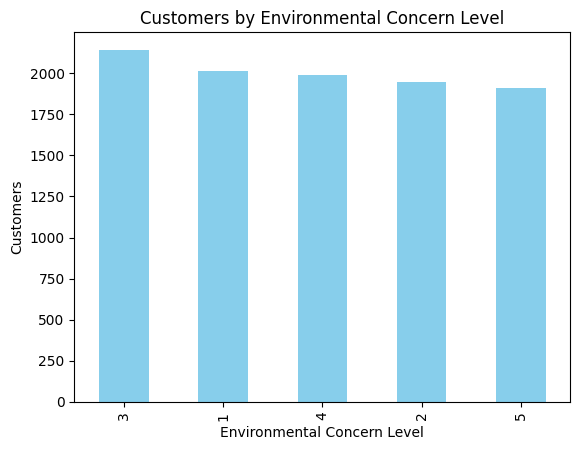

In [115]:
# Environmental Concern Level
df_clean["environmental_concern_level"].value_counts().plot(kind = "bar", color = "skyblue")
plt.title("Customers by Environmental Concern Level")
plt.xlabel("Environmental Concern Level")
plt.ylabel("Customers")
plt.show()

In [116]:
# Categorical Analysis
# analyze -  Gender, City type, Current car type, Home charging, Subsidy, Range anxiety, Will buy EV

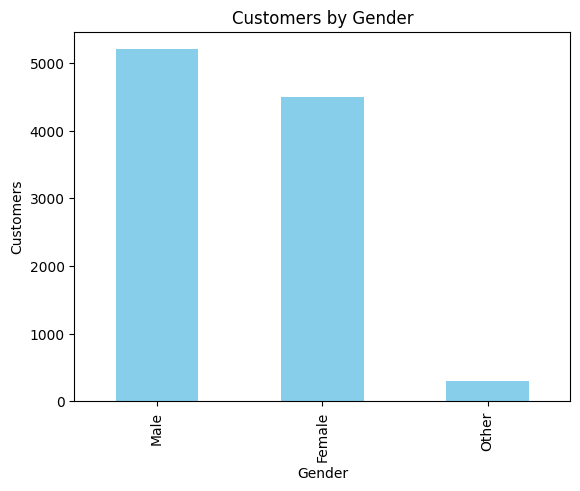

In [117]:
# Customers by Gender
df_clean["gender"].value_counts().plot(kind = "bar", color = "skyblue")
plt.title("Customers by Gender")
plt.xlabel("Gender")
plt.ylabel("Customers")
plt.show()

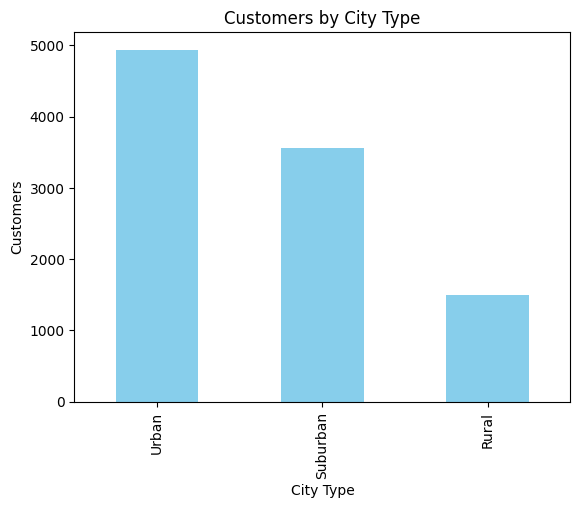

In [118]:
# Customers by City Type
df_clean["city_type"].value_counts().plot(kind = "bar", color = "skyblue")
plt.title("Customers by City Type")
plt.xlabel("City Type")
plt.ylabel("Customers")
plt.show()

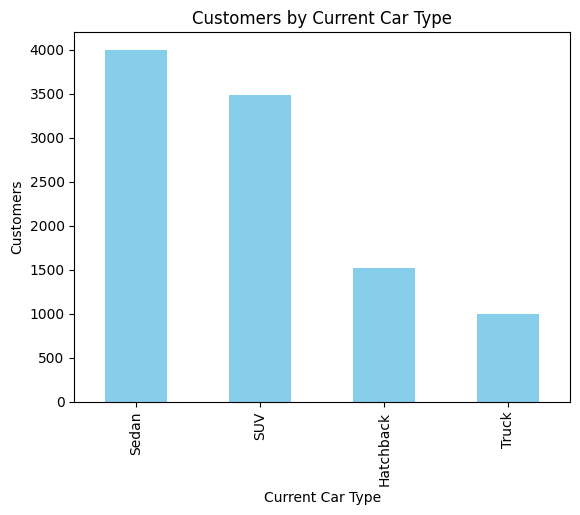

In [119]:
# Customers by Current Car Types
df_clean["current_car_type"].value_counts().plot(kind = "bar", color = "skyblue")
plt.title("Customers by Current Car Type")
plt.xlabel("Current Car Type")
plt.ylabel("Customers")
plt.show()

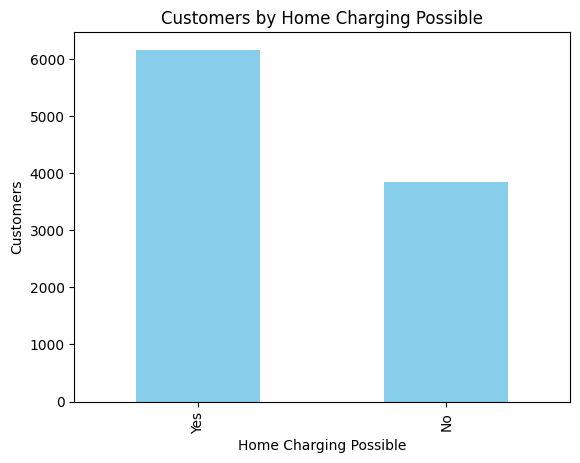

In [120]:
# Customers by Home Charging Possible 
df_clean["home_charging_possible"].value_counts().plot(kind = "bar", color = "skyblue")
plt.title("Customers by Home Charging Possible")
plt.xlabel("Home Charging Possible")
plt.ylabel("Customers")
plt.show()

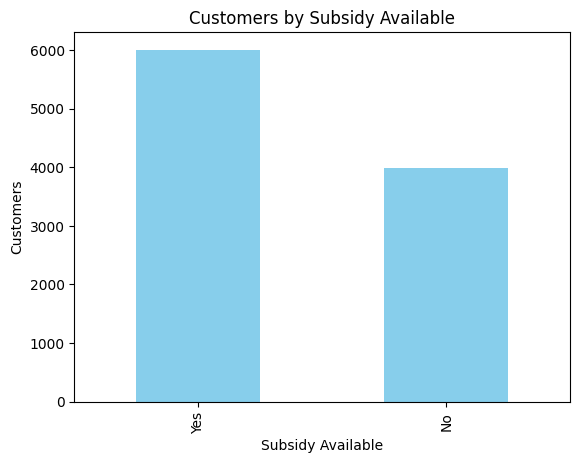

In [121]:
# Customers by Subsidy Available
df_clean["subsidy_available"].value_counts().plot(kind = "bar", color = "skyblue")
plt.title("Customers by Subsidy Available")
plt.xlabel("Subsidy Available")
plt.ylabel("Customers")
plt.show()

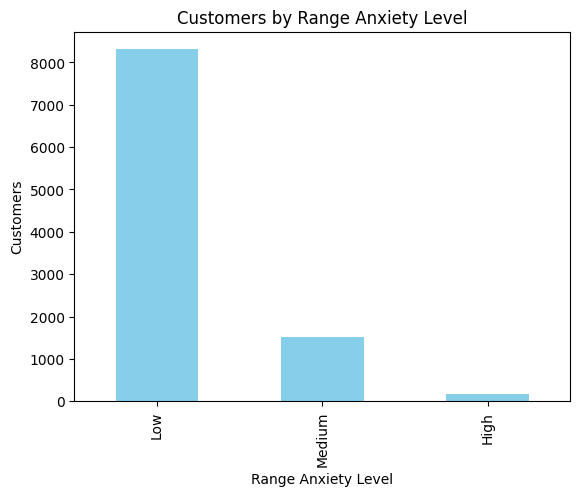

In [122]:
# Range Anxiety
df_clean["range_anxiety_level"].value_counts().plot(kind = "bar", color = "skyblue")
plt.title("Customers by Range Anxiety Level")
plt.xlabel("Range Anxiety Level")
plt.ylabel("Customers")
plt.show()

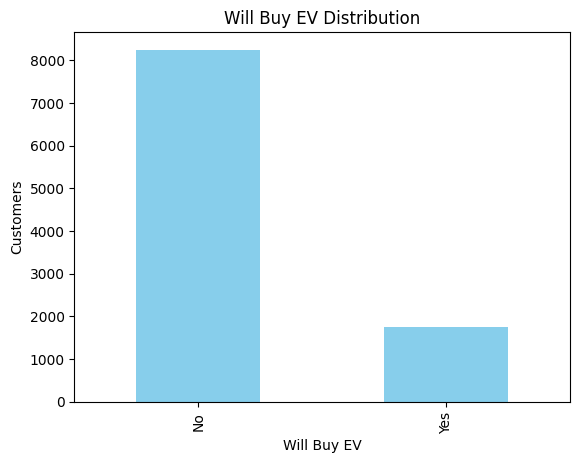

In [123]:
# Will Buy EV
df_clean["will_buy_ev"].value_counts().plot(kind = "bar", color = "skyblue")
plt.title("Will Buy EV Distribution")
plt.xlabel("Will Buy EV")
plt.ylabel("Customers")
plt.show()

In [124]:
# Bivariate Analysis

In [125]:
# EV adoption by gender
gender_ev = pd.crosstab(
    df_clean["gender"], df_clean["will_buy_ev"], normalize= "index"
) * 100
gender_ev

will_buy_ev,No,Yes
gender,,
Female,81.969764,18.030236
Male,82.907133,17.092867
Other,83.388704,16.611296


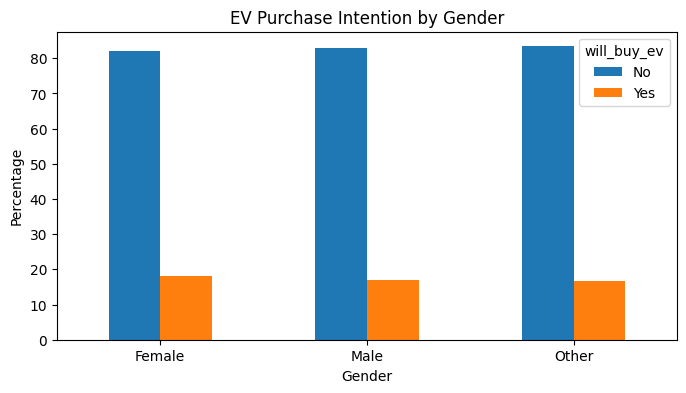

In [126]:
# Visulization
gender_ev.plot(kind = "bar", figsize=(8,4))
plt.title("EV Purchase Intention by Gender")
plt.ylabel("Percentage")
plt.xlabel("Gender")
plt.xticks(rotation=0)
plt.show()

In [127]:
# EV adoption by City Type
city_type_ev = pd.crosstab(
    df_clean["city_type"], df_clean["will_buy_ev"], normalize= "index"
) * 100
city_type_ev

will_buy_ev,No,Yes
city_type,,
Rural,81.016043,18.983957
Suburban,82.318271,17.681729
Urban,83.080348,16.919652


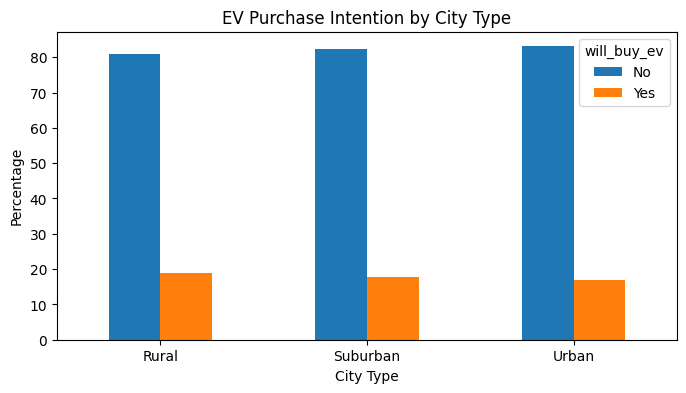

In [128]:
# visulization
city_type_ev.plot(kind = "bar", figsize=(8,4))
plt.title("EV Purchase Intention by City Type")
plt.ylabel("Percentage")
plt.xlabel("City Type")
plt.xticks(rotation=0)
plt.show()

In [129]:
# Range anxiety vs EV adoption
range_ev = pd.crosstab(
    df_clean["range_anxiety_level"], df_clean["will_buy_ev"], normalize= "index"
) * 100
range_ev

will_buy_ev,No,Yes
range_anxiety_level,,
High,99.401198,0.598802
Low,80.132371,19.867629
Medium,93.565332,6.434668


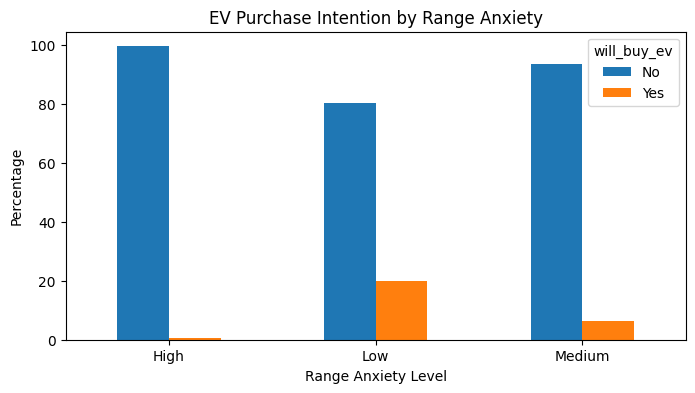

In [130]:
# Visualization
range_ev.plot(kind = "bar", figsize= (8, 4))
plt.title("EV Purchase Intention by Range Anxiety")
plt.ylabel("Percentage")
plt.xlabel("Range Anxiety Level")
plt.xticks(rotation=0)
plt.show()

In [131]:
# Environmental concern vs EV adoption
env_ev = pd.crosstab(
    df_clean["environmental_concern_level"], df_clean["will_buy_ev"], normalize= "index"
) * 100
env_ev

will_buy_ev,No,Yes
environmental_concern_level,,
1,97.863885,2.136115
2,95.071869,4.928131
3,85.154062,14.845938
4,74.710910,25.289090
5,58.595388,41.404612


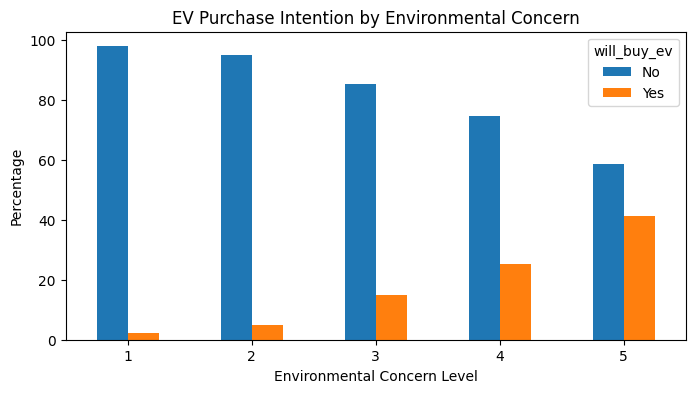

In [132]:
# Visualization
env_ev.plot(kind = "bar", figsize = (8, 4))
plt.title("EV Purchase Intention by Environmental Concern")
plt.ylabel("Percentage")
plt.xlabel("Environmental Concern Level")
plt.xticks(rotation=0)
plt.show()

In [133]:
# Subsidy vs EV adoption
subsidy_ev = pd.crosstab(
    df_clean["subsidy_available"], df_clean["will_buy_ev"], normalize= "index"
) * 100
subsidy_ev

will_buy_ev,No,Yes
subsidy_available,,
No,97.469940,2.530060
Yes,72.553262,27.446738


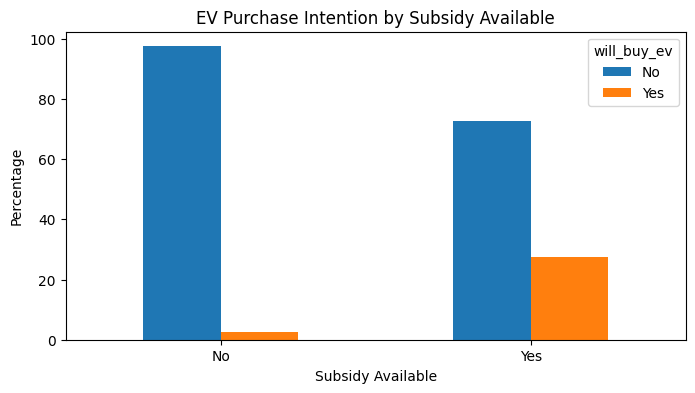

In [134]:
# Visualization
subsidy_ev.plot(kind = "bar", figsize = (8, 4))
plt.title("EV Purchase Intention by Subsidy Available")
plt.ylabel("Percentage")
plt.xlabel("Subsidy Available")
plt.xticks(rotation=0)
plt.show()

In [135]:
# Home charging vs EV adoption
charging_ev = pd.crosstab(
    df_clean["home_charging_possible"], df_clean["will_buy_ev"], normalize="index"
) * 100
charging_ev

will_buy_ev,No,Yes
home_charging_possible,,
No,86.630180,13.369820
Yes,79.928606,20.071394


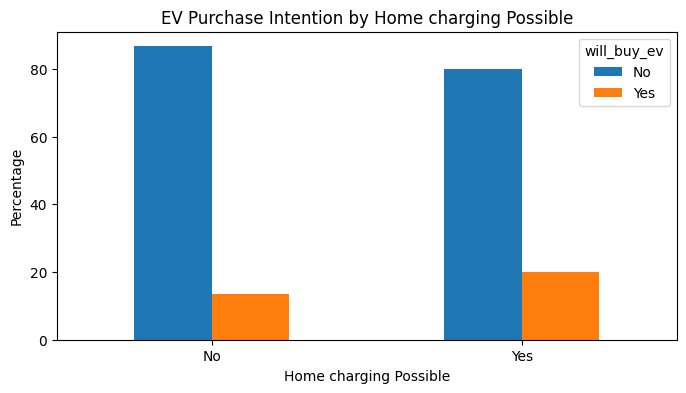

In [136]:
# Visualization
charging_ev.plot(kind = "bar", figsize = (8, 4))
plt.title("EV Purchase Intention by Home charging Possible")
plt.ylabel("Percentage")
plt.xlabel("Home charging Possible")
plt.xticks(rotation=0)
plt.show()

In [137]:
# Age Gropu vs EV adoption
age_group_ev = pd.crosstab(
    df_clean["age_group"], df_clean["will_buy_ev"], normalize= "index"
) * 100
age_group_ev

will_buy_ev,No,Yes
age_group,,
18-30,82.660688,17.339312
31-40,83.227848,16.772152
41-50,82.429501,17.570499
51-60,80.783410,19.216590
61-70,83.544304,16.455696


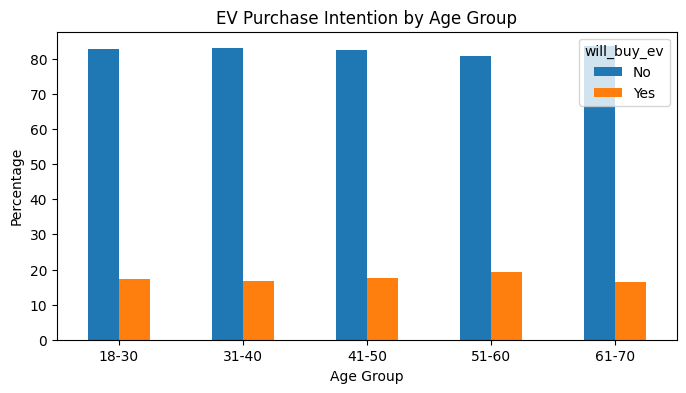

In [138]:
# Visualization
age_group_ev.plot(kind="bar", figsize=(8,4))

plt.title("EV Purchase Intention by Age Group")
plt.ylabel("Percentage")
plt.xlabel("Age Group")
plt.xticks(rotation=0)
plt.show()

In [139]:
# Numerical Variables vs EV Purchase

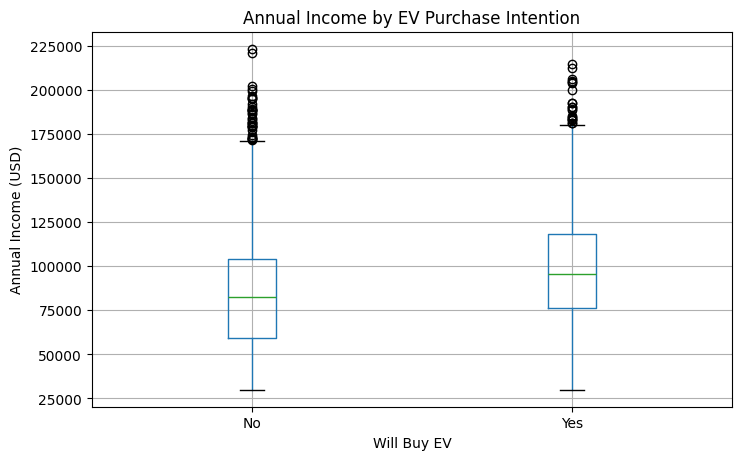

In [140]:
df_clean.boxplot(
    column="annual_income_usd",
    by="will_buy_ev",
    figsize=(8,5)
)

plt.title("Annual Income by EV Purchase Intention")
plt.suptitle("")
plt.xlabel("Will Buy EV")
plt.ylabel("Annual Income (USD)")
plt.show()

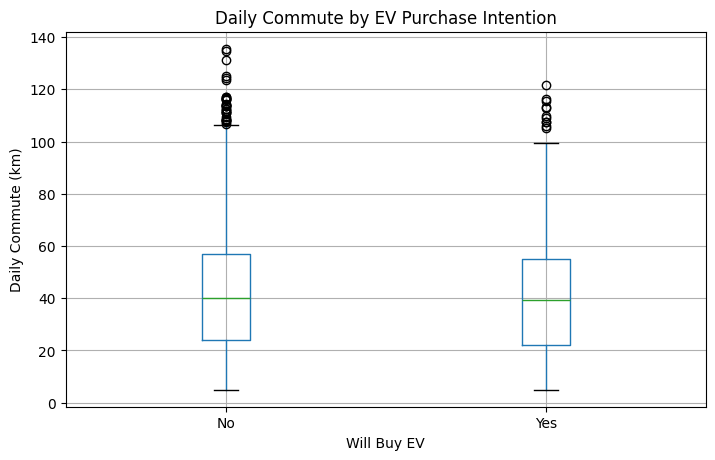

In [141]:
# Daily Commute
df_clean.boxplot(
    column="daily_commute_km",
    by="will_buy_ev",
    figsize=(8,5)
)

plt.title("Daily Commute by EV Purchase Intention")
plt.suptitle("")
plt.xlabel("Will Buy EV")
plt.ylabel("Daily Commute (km)")
plt.show()

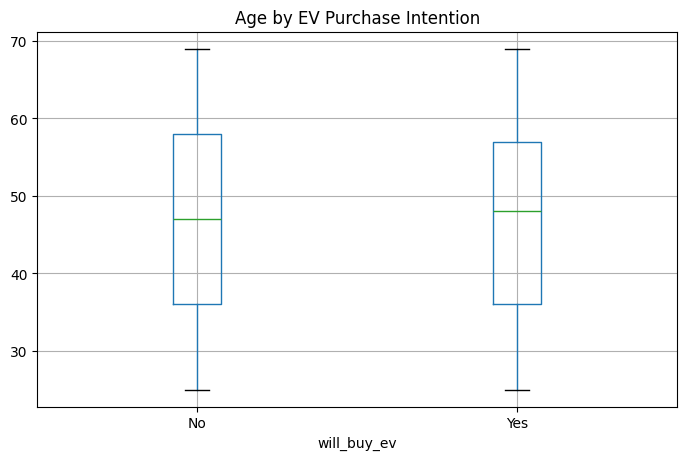

In [142]:
# age
df_clean.boxplot(
    column="age",
    by="will_buy_ev",
    figsize=(8,5)
)

plt.title("Age by EV Purchase Intention")
plt.suptitle("")
plt.show()

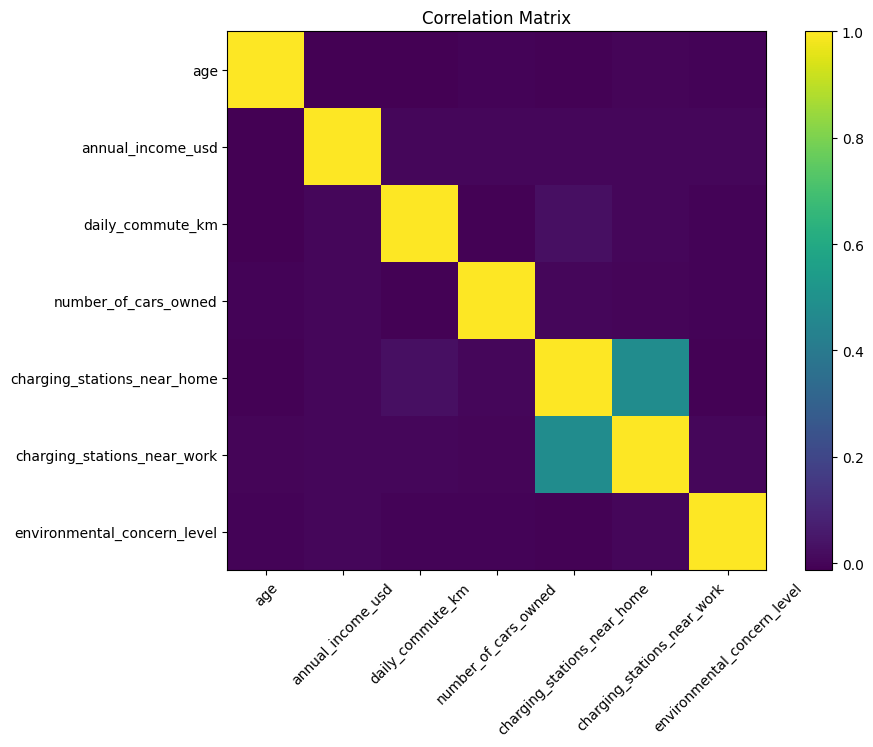

In [143]:
# Correlation Analysis
numeric_cols = [
    "age",
    "annual_income_usd",
    "daily_commute_km",
    "number_of_cars_owned",
    "charging_stations_near_home",
    "charging_stations_near_work",
    "environmental_concern_level"
]

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10,7))
plt.imshow(corr)
plt.colorbar()

plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)

plt.title("Correlation Matrix")
plt.show()

In [144]:
# Save the clean data
df_clean.to_csv("C:/Work/Projects/EV-Adoption-and-Range-Anxiety/01_data/ev_adoption_and_range_anxiety_clean.csv", index= False)

# Key Findings and Business Recommendations

In [145]:
# Key Findings

### Key Finding 1: Gender

# Female customers show slightly higher EV purchase intention compared with male and other-gender customers.

### Key Finding 2: City Type

# Customers from rural areas show slightly higher EV purchase intention compared with customers from urban and suburban areas.

### Key Finding 3: Range Anxiety Level

# Customers with low range anxiety show higher EV purchase intention compared with customers experiencing medium or high range anxiety. This suggests that range anxiety may be an important barrier to EV adoption.

### Key Finding 4: Environmental Concern Level

# Customers with higher environmental concern show greater EV purchase intention compared with customers with lower environmental concern. This suggests that environmental awareness may be associated with greater interest in EVs.

### Key Finding 5: Subsidy Availability

# Customers with access to subsidies show higher EV purchase intention compared with customers without subsidy availability. This indicates that financial incentives may be an important factor associated with EV adoption.

### Key Finding 6: Home Charging Availability

# Customers with home charging availability show higher EV purchase intention compared with customers without home charging access. Convenient charging infrastructure appears to be an important factor in EV adoption.

### Key Finding 7: Age Group

# Customers in the 41–50 and 51–60 age groups show higher EV purchase intention compared with some of the younger age groups.

### Key Finding 8: Annual Income

# Customers with higher annual income show greater EV purchase intention compared with lower-income customers, suggesting that purchasing power may be associated with EV adoption.

### Key Finding 9: Daily Commute

# Customers with shorter daily commutes show higher EV purchase intention compared with customers with longer daily commutes. This may indicate that range concerns become more important as daily travel distance increases.

# Business Recommendations

### Recommendation 1: Understand Gender Differences

# EV manufacturers should investigate the factors contributing to higher EV purchase intention among female customers and use these insights to develop more targeted marketing strategies across different customer segments.

### Recommendation 2: Learn from Rural EV Adoption

# Since rural customers show relatively higher EV purchase intention, manufacturers should investigate the characteristics and needs of this segment and identify successful factors that could potentially be applied to urban and suburban markets.

### Recommendation 3: Address Range Anxiety

# EV manufacturers should improve customer awareness about real-world vehicle range, charging infrastructure, and available driving ranges. Marketing campaigns and educational content can help customers better understand how EVs perform under different driving conditions.

### Recommendation 4: Promote Environmental Benefits

# EV manufacturers should communicate the environmental benefits of EV adoption through educational campaigns and sustainability initiatives. Highlighting how EVs can contribute to lower emissions may appeal to environmentally conscious customers.

### Recommendation 5: Improve Subsidy and Incentive Programs

# Manufacturers should work with governments and other stakeholders to promote available EV incentives and make customers more aware of subsidy programs, tax benefits, and other financial incentives.

### Recommendation 6: Improve Charging Accessibility

# EV manufacturers and charging providers should focus on expanding convenient charging infrastructure, particularly for customers who do not have access to home charging. Increasing the availability of charging stations can help address one of the potential barriers to EV adoption.

### Recommendation 7: Increase Awareness Among Younger Customers

# Since younger age groups show relatively lower EV purchase intention, manufacturers should develop targeted educational and marketing campaigns highlighting the economic, environmental, technological, and practical benefits of EV ownership.

### Recommendation 8: Address Affordability Concerns

# Manufacturers should explore ways to make EVs more affordable through competitive pricing, financing options, incentives, and lower-cost models to increase accessibility among lower-income customers.

### Recommendation 9: Address the Needs of Long-Distance Commuters

# Customers with longer daily commutes show lower EV purchase intention. Manufacturers should emphasize vehicle range, charging speed, charging-network availability, and real-world driving performance when targeting these customers. Expanding charging infrastructure along major commuting routes could also help reduce range-related concerns.
 